##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [3]:
!pip install -q keras-cv tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 13.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 18.1 MB/s eta 0:00:0000:01


In [4]:
# Import libraries
import tensorflow as tf
import keras_cv
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
# Load the model
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

In [ ]:
# Load the images
image_paths= [
    "/content/images/car.jfif",  # car
    "/content/images/cat.jfif",   # cat
    "/content/images/cow.jfif",  # cow
    "/content/images/dog.jfif",  # dog
    "/content/images/train.jfif"  # train
]

images = []

for path in image_paths:
    img = Image.open(path).convert("RGB")
    img = np.array(img)
    images.append(img)

In [ ]:
# Resize the images and convert to numpy array
inference_resizing = keras_cv.layers.Resizing(
    640, 640,
    pad_to_aspect_ratio=True,
    bounding_box_format="xywh"
)

images_resized = tf.stack([inference_resizing(tf.expand_dims(img, 0))[0] for img in images]).numpy()

In [ ]:
# Run the detector on images
predictions = model.predict(images_resized)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


In [ ]:
# map the classes
class_mapping = {
    0: "aeroplane",
    1: "bicycle",
    2: "bird",
    3: "boat",
    4: "bottle",
    5: "bus",
    6: "car",
    7: "cat",
    8: "chair",
    9: "cow",
    10: "diningtable",
    11: "dog",
    12: "horse",
    13: "motorbike",
    14: "person",
    15: "pottedplant",
    16: "sheep",
    17: "sofa",
    18: "train",
    19: "tvmonitor",
}

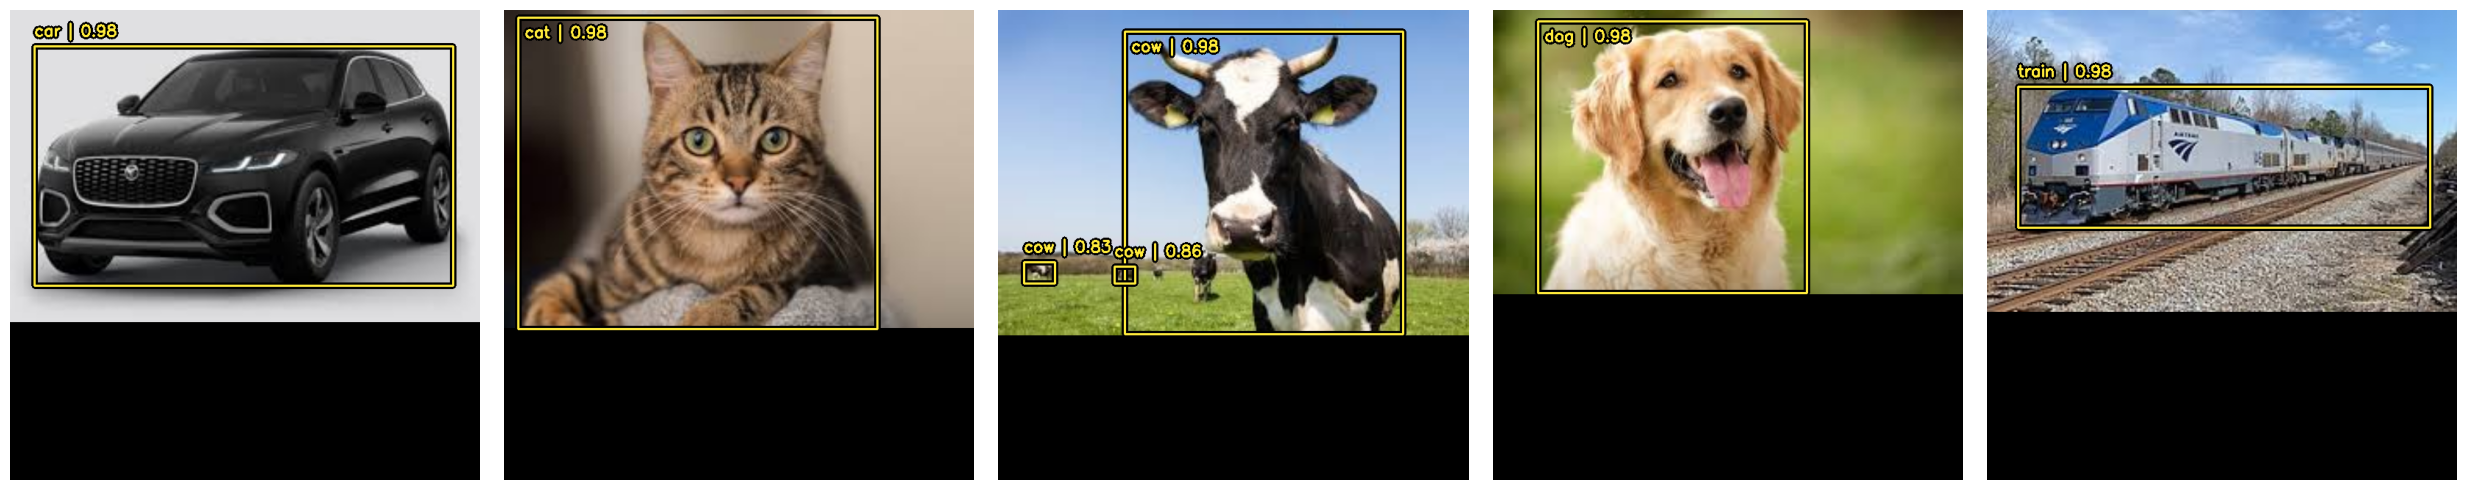

In [ ]:
# Visualize the detections
visualization = keras_cv.visualization.plot_bounding_box_gallery(
    images_resized,
    value_range=(0, 255),
    rows=1,
    cols=5,
    y_pred=predictions,
    scale=5,
    font_scale=0.7,
    bounding_box_format="xywh",
    class_mapping=class_mapping
)

In [ ]:
# All images were corectly detected 
# Image 1: car detected with 98% confidence
# Image 2: cat detected with 98% confidence
# Image 3: multiple cows detected with 98%,83%,86% confidences
# Image 4: dog detected with 98% confidence
# Image 5: train detected with 98% confidence